## Текстовое описание датасета

Будем использовать **Wine Dataset** из библиотеки `sklearn.datasets`.

Датасет содержит 178 образцов вина, 13 признаков (химические показатели) и 3 класса вин.  
Целевая переменная — `target` (1, 2, 3).  
Пропусков в исходных данных нет, но для демонстрации методов мы искусственно добавим пропуски.

## Основные характеристики

Проверим основные показатели: количество строк, столбцов, пропуски, уникальные значения и типы данных.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
%matplotlib inline
sns.set_style(style="ticks")

In [16]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target  # целевая переменная

np.random.seed(42)
for col in df.columns:
    mask = np.random.random(len(df)) < 0.05
    df.loc[mask, col] = np.nan

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,NaN,15.6,127.0,2.80,3.06,0.28,2.29,5.64,NaN,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,NaN,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,NaN,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,0.0


In [17]:
df.shape

(178, 14)

In [18]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,167.000000,166.000000,168.000000,172.000000,170.000000,166.000000,170.000000,167.000000,168.000000,173.000000,168.000000,172.000000,168.000000,168.000000
mean,12.985449,2.356928,2.363155,19.565116,99.752941,2.286446,2.037118,0.364431,1.573095,5.020116,0.953845,2.612616,752.755952,0.952381
std,0.816916,1.106308,0.271146,3.369497,14.392146,0.634983,0.994646,0.125115,0.554160,2.317378,0.229915,0.712344,318.993017,0.780062
min,11.030000,0.890000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.335000,1.615000,2.210000,17.200000,88.000000,1.705000,1.227500,0.270000,1.235000,3.170000,0.780000,1.952500,500.000000,0.000000
50%,13.050000,1.875000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.540000,4.600000,0.960000,2.780000,675.000000,1.000000
75%,13.655000,3.115000,2.540000,21.500000,107.000000,2.800000,2.875000,0.445000,1.950000,6.130000,1.120000,3.172500,996.250000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       167 non-null    float64
 1   malic_acid                    166 non-null    float64
 2   ash                           168 non-null    float64
 3   alcalinity_of_ash             172 non-null    float64
 4   magnesium                     170 non-null    float64
 5   total_phenols                 166 non-null    float64
 6   flavanoids                    170 non-null    float64
 7   nonflavanoid_phenols          167 non-null    float64
 8   proanthocyanins               168 non-null    float64
 9   color_intensity               173 non-null    float64
 10  hue                           168 non-null    float64
 11  od280/od315_of_diluted_wines  172 non-null    float64
 12  proline                       168 non-null    float64
 13  targe

In [20]:
for col in df.columns:
    missing_count = df[df[col].isnull()].shape[0]
    print(f"{col}: {missing_count}")

alcohol: 11
malic_acid: 12
ash: 10
alcalinity_of_ash: 6
magnesium: 8
total_phenols: 12
flavanoids: 8
nonflavanoid_phenols: 11
proanthocyanins: 10
color_intensity: 5
hue: 10
od280/od315_of_diluted_wines: 6
proline: 10
target: 10


In [21]:
for col in df.columns:
    if df[col].dtype == object:
        unique_count = df[col].unique().shape[0]
        print(f"{col}: {unique_count}")

In [22]:
df['alcohol_category'] = pd.cut(df['alcohol'], bins=3, labels=['Low', 'Medium', 'High'])
df['alcohol_category'].unique()

['High', 'Medium', NaN, 'Low']
Categories (3, object): ['Low' < 'Medium' < 'High']

## Кодирование категориальных признаков

У нас есть 3 основных способа кодирования категориальных фич:
- **Label Encoding** — назначаем числовые метки
- **One-hot Encoding** — создаём бинарные столбцы
- **Target Encoding** — заменяем на среднее целевой переменной

### Label Encoding

Для признаков с иерархией (Low, Medium, High) применим Label Encoding.

In [23]:
mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

df['alcohol_category_encoded'] = df['alcohol_category'].map(mapping)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_category,alcohol_category_encoded
0,14.23,1.71,NaN,15.6,127.0,2.80,3.06,0.28,2.29,5.64,NaN,3.92,1065.0,0.0,High,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,NaN,1.28,4.38,1.05,3.40,1050.0,0.0,Medium,1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,NaN,5.68,1.03,3.17,1185.0,0.0,Medium,1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0,High,2
4,13.24,2.59,2.87,21.0,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,0.0,Medium,1


### One-hot Encoding

Для категориального признака `alcohol_category` применим One-hot Encoding.

In [24]:
df = pd.get_dummies(df, columns=['alcohol_category'], dummy_na=True)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_category_encoded,alcohol_category_Low,alcohol_category_Medium,alcohol_category_High,alcohol_category_nan
0,14.23,1.71,NaN,15.6,127.0,2.80,3.06,0.28,2.29,5.64,NaN,3.92,1065.0,0.0,2,False,False,True,False
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,NaN,1.28,4.38,1.05,3.40,1050.0,0.0,1,False,True,False,False
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,NaN,5.68,1.03,3.17,1185.0,0.0,1,False,True,False,False
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0,2,False,False,True,False
4,13.24,2.59,2.87,21.0,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,0.0,1,False,True,False,False


### Target Encoding

Заменяем категории на среднее значение целевого признака `target`.

In [25]:
target_mean = df.groupby('alcohol_category_encoded')['target'].mean()
df['alcohol_target_encoded'] = df['alcohol_category_encoded'].map(target_mean)
df.head()

C:\Users\alexa\AppData\Local\Temp\ipykernel_32720\4210059420.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mean = df.groupby('alcohol_category_encoded')['target'].mean()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_category_encoded,alcohol_category_Low,alcohol_category_Medium,alcohol_category_High,alcohol_category_nan,alcohol_target_encoded
0,14.23,1.71,NaN,15.6,127.0,2.80,3.06,0.28,2.29,5.64,NaN,3.92,1065.0,0.0,2,False,False,True,False,0.511628
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,NaN,1.28,4.38,1.05,3.40,1050.0,0.0,1,False,True,False,False,1.144737
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,NaN,5.68,1.03,3.17,1185.0,0.0,1,False,True,False,False,1.144737
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0,2,False,False,True,False,0.511628
4,13.24,2.59,2.87,21.0,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,0.0,1,False,True,False,False,1.144737


## Заполнение пропусков в данных

Способы: константой, моделью, удаление признаков.

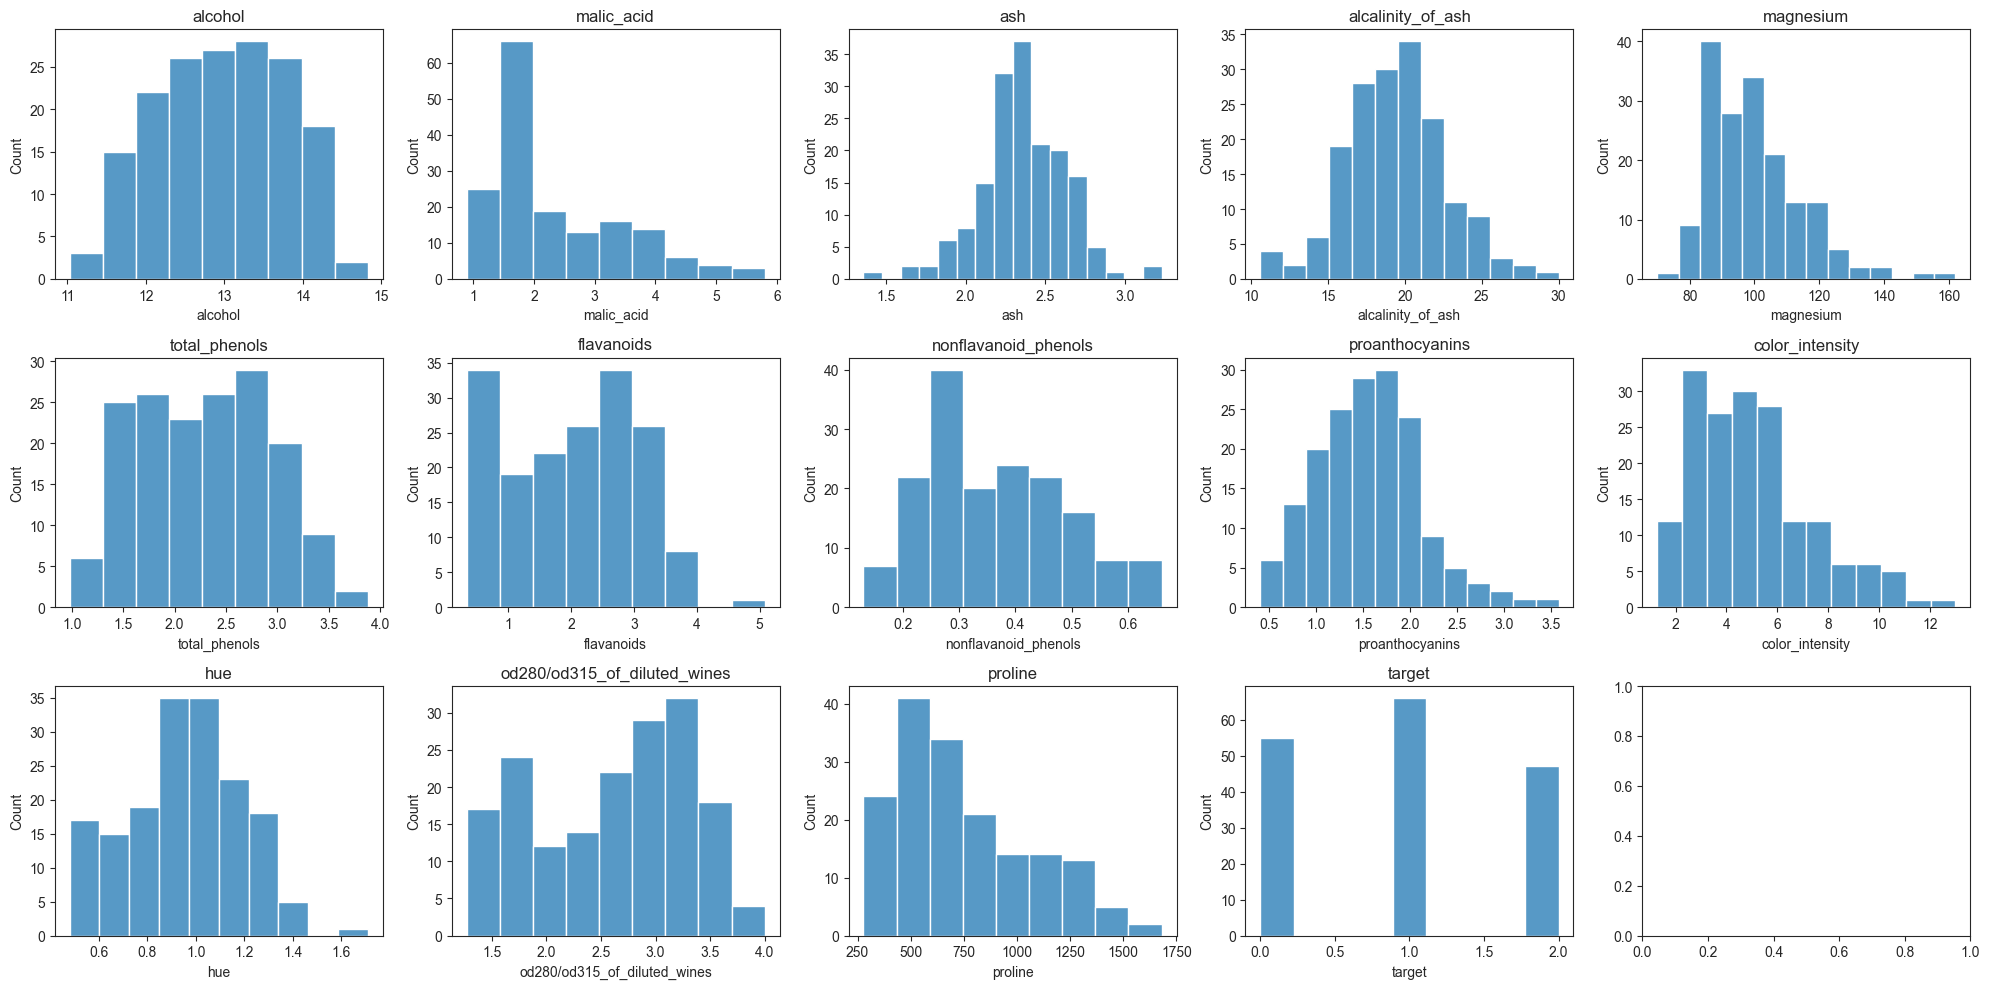

In [26]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

cols = df.select_dtypes(include=[np.number]).columns[:15]
for i, col in enumerate(cols):
    ax = axes[i // 5, i % 5]
    sns.histplot(df[col].dropna(), ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Заполнение константой

Числовые признаки — средним, категории — модой/медианой.

In [27]:
mean_cols = df.select_dtypes(include=[np.number]).columns
mean_cols = [c for c in mean_cols if c != 'target' and 'encoded' not in c]

for col in mean_cols[:5]:  # для демонстрации
    df[col].fillna(df[col].mean(), inplace=True)

df.isna().sum()

C:\Users\alexa\AppData\Local\Temp\ipykernel_32720\1480827267.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


alcohol                          0
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                   12
flavanoids                       8
nonflavanoid_phenols            11
proanthocyanins                 10
color_intensity                  5
hue                             10
od280/od315_of_diluted_wines     6
proline                         10
target                          10
alcohol_category_encoded        11
alcohol_category_Low             0
alcohol_category_Medium          0
alcohol_category_High            0
alcohol_category_nan             0
alcohol_target_encoded          11
dtype: int64

In [ ]:
median_cols = ['alcohol_category_encoded', 'alcohol_target_encoded']

for col in median_cols:
    if col in df.columns:
        if pd.api.types.is_categorical_dtype(df[col]) or df[col].dtype == 'category':
            df[col] = df[col].astype(float)
        
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

df.isna().sum()

C:\Users\alexa\AppData\Local\Temp\ipykernel_32720\1276785572.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]) or df[col].dtype == 'category':
C:\Users\alexa\AppData\Local\Temp\ipykernel_32720\1276785572.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\alexa\AppData\Local\Temp\ipykernel_32720\1276785572.py:6: DeprecationWarni

alcohol                          0
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                   12
flavanoids                       8
nonflavanoid_phenols            11
proanthocyanins                 10
color_intensity                  5
hue                             10
od280/od315_of_diluted_wines     6
proline                         10
target                          10
alcohol_category_encoded         0
alcohol_category_Low             0
alcohol_category_Medium          0
alcohol_category_High            0
alcohol_category_nan             0
alcohol_target_encoded           0
dtype: int64

### Предсказание пропусков с помощью KNN

Используем `KNNImputer` из sklearn.

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric),
    columns=numeric_cols
)

non_numeric = df.select_dtypes(exclude=[np.number]).columns
df = pd.concat([df_imputed, df[non_numeric].reset_index(drop=True)], axis=1)

df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
alcohol_category_encoded        0
alcohol_target_encoded          0
alcohol_category_Low            0
alcohol_category_Medium         0
alcohol_category_High           0
alcohol_category_nan            0
dtype: int64